# Homework 4
November 8, 2025

### Importing Libraries & Set Seed:

In [1]:
import numpy as np
import pandas as pd
from tensorflow import random
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, GRU, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Set Seed:
seed = 4337
np.random.seed(seed)
random.set_seed(seed)

### Data Loading and Initial Exploration:

In [2]:
# 1. Load Data:
data_path = "NFLX.csv"

# YOUR CODE HERE: Load the dataset from the url into a pandas DataFrame named 'df'.
# Make sure to parse the 'Date' column as datetime objects using the 'parse_dates' argument.
df = pd.read_csv(data_path, parse_dates=['Date'])

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Display basic info about the DataFrame
print("\nDataFrame Info:")
print(df.info())

First 5 rows of the dataset:
        Date        Open        High         Low       Close   Adj Close  \
0 2018-02-05  262.000000  267.899994  250.029999  254.259995  254.259995   
1 2018-02-06  247.699997  266.700012  245.000000  265.720001  265.720001   
2 2018-02-07  266.579987  272.450012  264.329987  264.559998  264.559998   
3 2018-02-08  267.079987  267.619995  250.000000  250.100006  250.100006   
4 2018-02-09  253.850006  255.800003  236.110001  249.470001  249.470001   

     Volume  
0  11896100  
1  12595800  
2   8981500  
3   9306700  
4  16906900  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1009 non-null   datetime64[ns]
 1   Open       1009 non-null   float64       
 2   High       1009 non-null   float64       
 3   Low        1009 non-null   float64       
 4   Close      1009 non-

### Select Target Variable & Visualize:
We are selecting the 'Close' price as our target variable and plotting it over time. We need to isolate the variable we want to predict. Plotting helps visualize the trends, seasonality, and potential challenges in the data.

Shape of close_prices: (1009, 1)


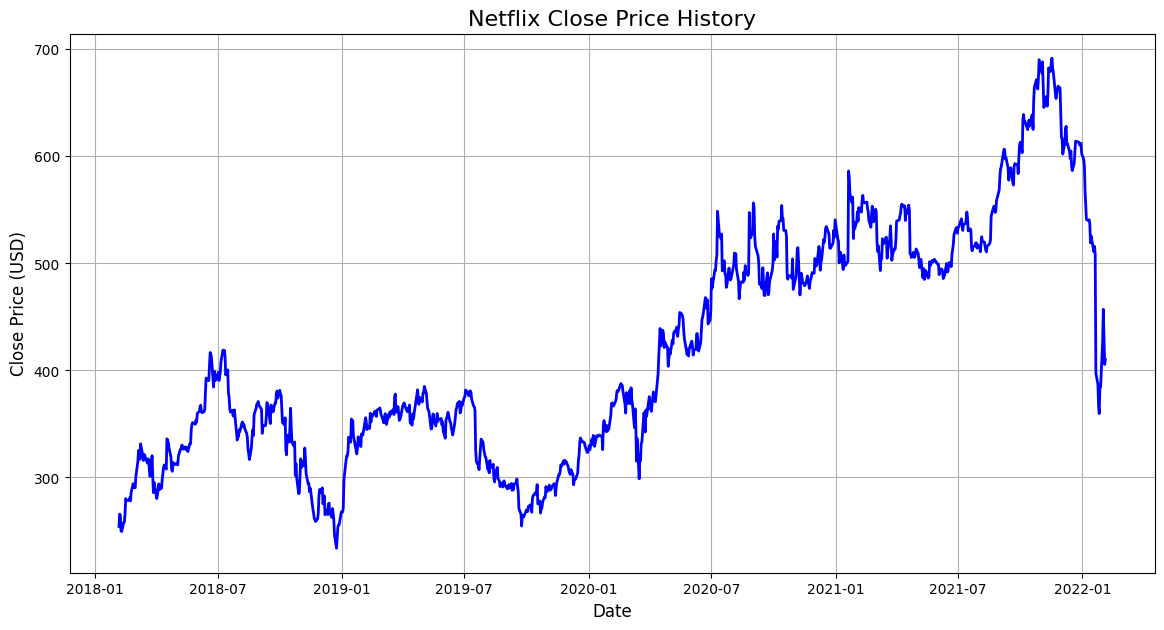

In [3]:
# 2a. Select Target Variable:
# YOUR CODE HERE: Extract the 'Close' column as a numpy array, ensure it's float32, and reshape it to be a 2D array (samples, 1 feature).
# Store this in a variable called 'close_prices'.
close_prices = df['Close'].values.astype('float32').reshape(-1, 1)

print(f"Shape of close_prices: {close_prices.shape}")

# 2b. Visualize the Close Price:
plt.figure(figsize=(14, 7))

# YOUR CODE HERE: Plot the 'Date' column from the DataFrame 'df' on the x-axis and the 'close_prices' array on the y-axis.
# Add a title 'Netflix Close Price History', xlabel 'Date', and ylabel 'Close Price USD'.
plt.plot(df['Date'], close_prices, color='blue', linewidth=2)
plt.title('Netflix Close Price History', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (USD)', fontsize=12)
plt.grid(True)
plt.show()

### Scale the Data:
Neural networks generally perform better with normalized input data. Scaling prevents features with large values from disproportionately influencing the model's learning process and helps gradients flow more effectively.

In [4]:
# 3. Scale the Data:
# YOUR CODE HERE: Initialize a MinMaxScaler with feature_range=(0, 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# YOUR CODE HERE: Apply scaler 2 'close_prices' using fit_transform & store th/result in 'dataset_scaled'
dataset_scaled = scaler.fit_transform(close_prices)

print("Shape of scaled dataset:", dataset_scaled.shape)
print("First 5 scaled values:\n", dataset_scaled[:5])

Shape of scaled dataset: (1009, 1)
First 5 scaled values:
 [[0.04451627]
 [0.06954849]
 [0.06701463]
 [0.03542954]
 [0.03405339]]


### Define Sequence Creation Function:
We are creating a reusable function to transform the time series data into input sequences (X) and target outputs (y).
Define a function `create_sequences` that takes the scaled data and `look_back` period as input. It iterates through the data, creating sequences of length `look_back` and pairing them with the immediately following data point as the target. RNNs require input data structured as sequences. This function automates the process of generating these sequence-target pairs, which is fundamental for training.

In [5]:
# 4. Define Sequence Creation Function:
def create_sequences(data, look_back=1):
    """Converts univariate time series data into sequences for RNNs."""
    X, y = [], []
    for i in range(len(data) - look_back):
        sequence = data[i:(i + look_back), 0]
        target = data[i + look_back, 0]
        X.append(sequence)
        y.append(target)
    return np.array(X), np.array(y)

# Test the function (optional)
test_data = np.arange(10).reshape(-1, 1)
testX, testY = create_sequences(test_data, 3)
print("Test Data:\n", test_data.flatten())
print("\nTest X (look_back=3):\n", testX)
print("\nTest Y (look_back=3):\n", testY)

Test Data:
 [0 1 2 3 4 5 6 7 8 9]

Test X (look_back=3):
 [[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]
 [6 7 8]]

Test Y (look_back=3):
 [3 4 5 6 7 8 9]


### Create Sequences and Reshape:
We are applying the `create_sequences` function and reshaping the resulting input data `X`.
Call the function with the scaled data and the desired `look_back`. Then use `np.reshape` on `X`.
We are doing this to generate the actual training/testing sequences based on our chosen lookback period (e.g., 60 days). The reshaping step is mandatory to get the 3D format `[samples, timesteps, features]` required by Keras RNN layers.

In [6]:
# 5a. Create Sequences:
# We'll use the past 60 days (timesteps) to predict the next day.
look_back = 60

# YOUR CODE HERE: Call the 'create_sequences' function with 'dataset_scaled' and 'look_back'.
# Store the results in variables 'X' and 'y'.
X, y = create_sequences(dataset_scaled, look_back)

print(f"Created {X.shape[0]} sequences.")
print("Shape of X before reshape:", X.shape)
print("Shape of y:", y.shape)

# 5b. Reshape Input Data for RNN:
# Reshape X to the required 3D format: [samples, time steps, features]
# YOUR CODE HERE: Reshape 'X' using np.reshape. The new shape should have:
# - X.shape[0] as the number of samples
# - X.shape[1] (which is look_back) as the number of timesteps
# - 1 as the number of features (since we are only using 'Close' price)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print("Shape of X after reshape:", X.shape)

Created 949 sequences.
Shape of X before reshape: (949, 60)
Shape of y: (949,)
Shape of X after reshape: (949, 60, 1)


### Split Data into Training & Testing Sets:
We are dividing the sequential data into a set for training the model and a separate set for evaluating its performance.
Calculate a split point (e.g., 80% mark) and slicing the `X` and `y` arrays. 
For time series forecasting, the model must learn from the past to predict the future. We train on the earlier portion of the data and test on the later portion to mimic this real-world scenario.

**Crucial to notice that we do not shuffle the data.**

In [7]:
# 6. Train/Test Split (Sequential):
# Use 80% of the data for training, 20% for testing.
train_size_percentage = 0.8

# YOUR CODE HERE: Calculate the integer index 'train_size' representing the end of the training data.
train_size = int(len(X) * train_size_percentage)

# YOUR CODE HERE: Slice the 'X' and 'y' arrays to create:
# - X_train, y_train (from the beginning up to train_size)
# - X_test, y_test (from train_size to the end)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Verification:
print("Split Shapes:")
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Split Shapes:
Shape of X_train: (759, 60, 1)
Shape of y_train: (759,)
Shape of X_test: (190, 60, 1)
Shape of y_test: (190,)


## Exercise 1: Build & Compare RNN Models:
### 1a. Define Model Architectures:
Specify the layers for each model.
Use `Sequential()` and add the appropriate RNN layer (`SimpleRNN`, `GRU`, `LSTM`) with 32 units, followed by a `Dense` output layer with 1 unit.
This sets up the structure of each network. 32 units is an arbitrary starting point for hidden layer complexity. The `Dense(1)` layer is required for our regression task (predicting one continuous value).

In [8]:
# Define Input Shape:
input_shape = (look_back, 1)

# Define Model 1 (SimpleRNN):
model_rnn = Sequential(name="SimpleRNN_Model")
# YOUR CODE HERE: Add a SimpleRNN layer with 32 units. Specify the input_shape.
model_rnn.add(SimpleRNN(32, input_shape=input_shape))
# YOUR CODE HERE: Add a Dense output layer with 1 unit.
model_rnn.add(Dense(1))

# --- Define Model 2 (GRU) ---
model_gru = Sequential(name="GRU_Model")
# YOUR CODE HERE: Add a GRU layer with 32 units. Specify the input_shape.
model_gru.add(GRU(32, input_shape=input_shape))
# YOUR CODE HERE: Add a Dense output layer with 1 unit.
model_gru.add(Dense(1))

# --- Define Model 3 (LSTM) ---
model_lstm = Sequential(name="LSTM_Model")
# YOUR CODE HERE: Add an LSTM layer with 32 units. Specify the input_shape.
model_lstm.add(LSTM(32, input_shape=input_shape))
# YOUR CODE HERE: Add a Dense output layer with 1 unit.
model_lstm.add(Dense(1))

print("Models defined.")

C:\Users\isrtr\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Models defined.


### 1b. Compile Models:

In [9]:
# Compile all models:
print("Compiling models...")
# YOUR CODE HERE: Compile model_rnn with 'adam' optimizer and 'mean_squared_error' loss:
model_rnn.compile(optimizer='adam', loss='mean_squared_error')

# YOUR CODE HERE: Compile model_gru similarly:
model_gru.compile(optimizer='adam', loss='mean_squared_error')

# YOUR CODE HERE: Compile model_lstm similarly:
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Print Model Summary (Example):
print("\nModel 3 (LSTM) Summary")
model_lstm.summary()

Compiling models...

Model 3 (LSTM) Summary


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

### 1c. Train the Models:
We use `validation_split=0.1` to monitor performance on unseen data during training.

In [10]:
# Training parameters
epochs = 50 # Number of passes through the entire training dataset.
batch_size = 32 # Number of samples processed before the model's weights are updated.

print(f"Training Model 1 (SimpleRNN) for {epochs} epochs...")
# YOUR CODE HERE: Train 'model_rnn' using .fit().
# Pass X_train, y_train, epochs, batch_size, validation_split=0.1, and verbose=1.
# Store the output history in 'history_rnn'.
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)

Training Model 1 (SimpleRNN) for 50 epochs...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0970 - val_loss: 0.0051
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0021 - val_loss: 0.0024
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0019 - val_loss: 0.0023
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0018 - val_loss: 0.0022
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0016 - val_loss: 0.0021
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 12/50
22/22

In [11]:
print(f"\nTraining Model 2 (GRU) for {epochs} epochs...")
# YOUR CODE HERE: Train 'model_gru' similarly to model_rnn.
# Store the output history in 'history_gru'.
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)


Training Model 2 (GRU) for 50 epochs...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - loss: 0.0719 - val_loss: 0.0089
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0110 - val_loss: 0.0289
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0061 - val_loss: 0.0078
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0031 - val_loss: 0.0044
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 9.6165e-04 - val_loss: 0.0015
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 9.4420e-04 - val_loss: 0.0015
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 9.2902e-04 - val_loss: 0.0014
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 9.1154e-04 - val_loss: 0.0014
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 8.9347e-04 - val_loss: 0.0014
Ep

In [12]:
print(f"\nTraining Model 3 (LSTM) for {epochs} epochs...")
# YOUR CODE HERE: Train 'model_lstm' similarly to model_rnn.
# Store the output history in 'history_lstm'.
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)

print("\nAll models trained successfully!")


Training Model 3 (LSTM) for 50 epochs...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0873 - val_loss: 0.0023
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0092 - val_loss: 0.0207
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0048 - val_loss: 0.0048
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0027 - val_loss: 0.0024
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0021 - val_loss: 0.0030
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0020 - val_loss: 0.0032
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0020 - val_loss: 0.0030
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0020 - val_loss: 0.0029
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0020 - val_loss: 0.0028
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0019 - val_loss: 0.0028
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0019 - val_loss: 0.0027
Epoch 12/50
22/22 ━━━

### 1d. Evaluate Models on Test Data:

In [13]:
# === Evaluate Models on Test Set ===
print("\nEvaluating models on the test set...")

# YOUR CODE HERE: Evaluate 'model_rnn' on X_test and y_test. Store the result in 'mse_rnn'.
# Set verbose=0 to avoid printing evaluation progress.
mse_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
print(f"Model 1 (SimpleRNN) - Test MSE: {mse_rnn:.6f}")

# YOUR CODE HERE: Evaluate 'model_gru' on X_test and y_test. Store the result in 'mse_gru'.
mse_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print(f"Model 2 (GRU) - Test MSE: {mse_gru:.6f}")

# YOUR CODE HERE: Evaluate 'model_lstm' on X_test and y_test. Store the result in 'mse_lstm'.
mse_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f"Model 3 (LSTM) - Test MSE: {mse_lstm:.6f}")

# Calculate Root Mean Squared Error (RMSE) for better interpretability (optional)
rmse_rnn = np.sqrt(mse_rnn)
rmse_gru = np.sqrt(mse_gru)
rmse_lstm = np.sqrt(mse_lstm)

print(f"\nModel 1 (SimpleRNN) - Test RMSE: {rmse_rnn:.6f} (scaled units)")
print(f"Model 2 (GRU) - Test RMSE: {rmse_gru:.6f} (scaled units)")
print(f"Model 3 (LSTM) - Test RMSE: {rmse_lstm:.6f} (scaled units)")


Evaluating models on the test set...
Model 1 (SimpleRNN) - Test MSE: 0.001137
Model 2 (GRU) - Test MSE: 0.000974
Model 3 (LSTM) - Test MSE: 0.001879

Model 1 (SimpleRNN) - Test RMSE: 0.033726 (scaled units)
Model 2 (GRU) - Test RMSE: 0.031204 (scaled units)
Model 3 (LSTM) - Test RMSE: 0.043342 (scaled units)


## Exercise 2: More Evaluation & Tuning Experiments
### 21. Plotting Learning Curves
We will visualize how training and validation loss changed during training for each model.
Define a function to plot `loss` and `val_loss` from a model's history object. Call this function for each of the three trained models.
This helps diagnose **overfitting**.


Plotting Loss Curves for Each Model...


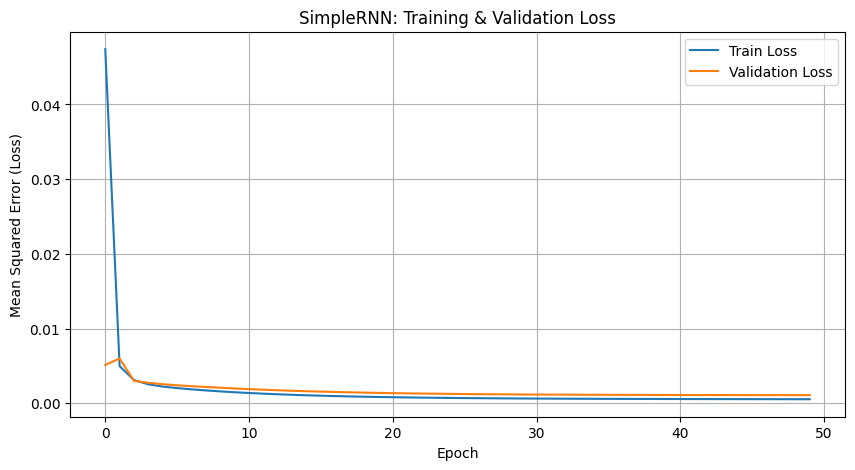

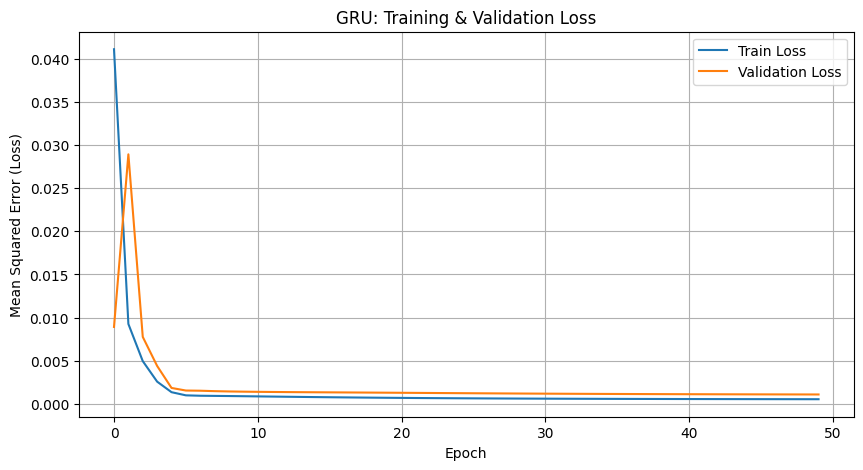

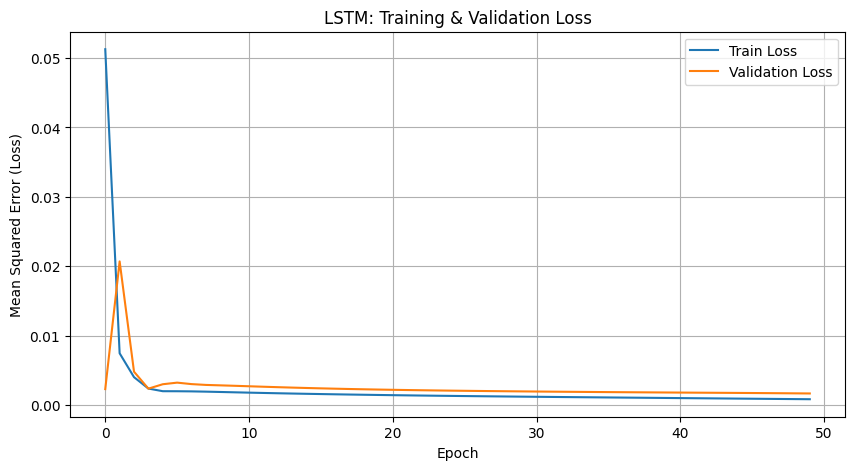

In [14]:
def plot_loss_curves(history, model_name):
    plt.figure(figsize=(10, 5))
    # YOUR CODE HERE: Plot the training loss (history.history['loss'])
    plt.plot(history.history['loss'], label='Train Loss')
    # YOUR CODE HERE: Plot the validation loss (history.history['val_loss'])
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name}: Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (Loss)')
    plt.legend()
    plt.grid(True)
    plt.show()

print("\nPlotting Loss Curves for Each Model...")
# YOUR CODE HERE: Call plot_loss_curves for history_rnn with model name 'SimpleRNN'.
plot_loss_curves(history_rnn, "SimpleRNN")

# YOUR CODE HERE: Call plot_loss_curves for history_gru with model name 'GRU'.
plot_loss_curves(history_gru, "GRU")

# YOUR CODE HERE: Call plot_loss_curves for history_lstm with model name 'LSTM'.
plot_loss_curves(history_lstm, "LSTM")

### 2b. Plotting Predictions vs. Actual
We will compare the models predictions on the test set against the actual stock prices visually. We can see if the models capture the overall trend, magnitude, and turning points of the actual stock price.

In [ ]:
print("\nGenerating predictions for final plot...")
# Make Predictions:
# YOUR CODE HERE: Predict on X_test using model_rnn, store in test_predict_rnn
test_predict_rnn = model_rnn.predict(X_test)
# YOUR CODE HERE: Predict on X_test using model_gru, store in test_predict_gru
test_predict_gru = model_gru.predict(X_test)
# YOUR CODE HERE: Predict on X_test using model_lstm, store in test_predict_lstm
test_predict_lstm = model_lstm.predict(X_test)

# Inverse Transform Predictions:
# What: Convert scaled predictions (0-1 range) back to original dollar values.
# How: Use scaler.inverse_transform().
# Why: To compare predictions directly with the actual stock prices.
# YOUR CODE HERE: Inverse transform test_predict_rnn
test_predict_rnn = scaler.inverse_transform(test_predict_rnn)
# YOUR CODE HERE: Inverse transform test_predict_gru
test_predict_gru = scaler.inverse_transform(test_predict_gru)
# YOUR CODE HERE: Inverse transform test_predict_lstm
test_predict_lstm = scaler.inverse_transform(test_predict_lstm)

# Inverse Transform Actual Test Data:
# YOUR CODE HERE: Inverse transform y_test. Reshape y_test to 2D first using .reshape(-1, 1).
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plotting:
plt.figure(figsize=(15, 7))

# Get the dates corresponding to the test set
test_dates = df['Date'].iloc[train_size+look_back:]

# YOUR CODE HERE: Plot the actual test data (test_dates vs y_test_actual). Label it 'Actual Netflix Close Price'.
plt.plot(test_dates, y_test_actual, label='Actual Netflix Close Price')

# YOUR CODE HERE: Plot the RNN test predictions (test_dates vs test_predict_rnn). Label it 'RNN Test Prediction'. Use linestyle='--'.
plt.plot(test_dates, test_predict_rnn, '--', label='RNN Test Prediction')

# YOUR CODE HERE: Plot the GRU test predictions (test_dates vs test_predict_gru). Label it 'GRU Test Prediction'. Use linestyle='--'.
plt.plot(test_dates, test_predict_gru, '--', label='GRU Test Prediction')

# YOUR CODE HERE: Plot the LSTM test predictions (test_dates vs test_predict_lstm). Label it 'LSTM Test Prediction'. Use linestyle='--'.
plt.plot(test_dates, test_predict_lstm, '--', label='LSTM Test Prediction')

plt.title('Netflix Stock Price Prediction Comparison (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

### 2c. Experiment: Stacked LSTM:
We will build a deeper LSTM network with two layers. By Adding a second `LSTM(32)` layer. The *first* LSTM layer needs `return_sequences=True`.
Stacking allows the network to potentially learn more complex, hierarchical temporal patterns.


--- Experiment: Stacked LSTM ---


C:\Users\isrtr\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Stacked_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)


Training Stacked LSTM for 50 epochs...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - loss: 0.0623 - val_loss: 0.0192
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0050 - val_loss: 0.0030
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0025 - val_loss: 0.0029
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0025 - val_loss: 0.0035
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0025 - val_loss: 0.0036
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0025 - val_loss: 0.0037
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0024 - val_loss: 0.0038
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0023 - val_loss: 0.0037
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0021 - val_loss: 0.0034
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0021 - val_loss: 0.0033
Epoch 12/50
22/22 ━━━

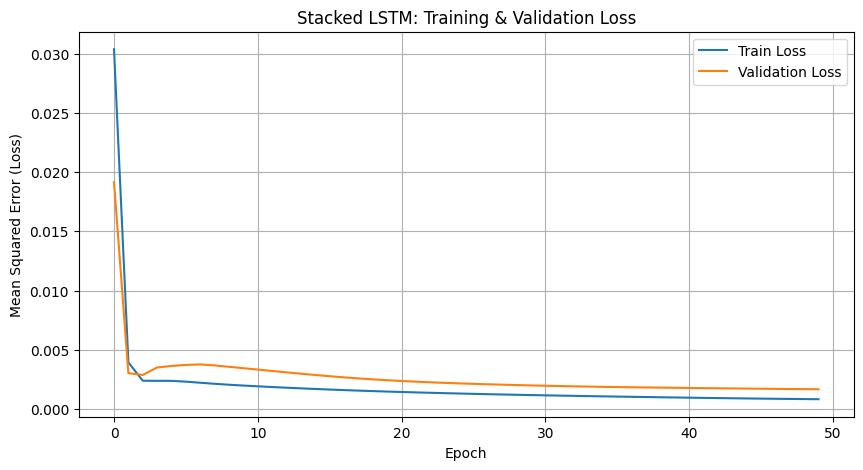

In [15]:
print("\n--- Experiment: Stacked LSTM ---")
model_stacked_lstm = Sequential(name="Stacked_LSTM_Model")

# YOUR CODE HERE: Add the first LSTM layer with 32 units.
# Remember to set return_sequences=True and specify input_shape.
model_stacked_lstm.add(LSTM(32, return_sequences=True, input_shape=input_shape))

# YOUR CODE HERE: Add the second LSTM layer with 32 units.
# return_sequences defaults to False, which is correct here.
model_stacked_lstm.add(LSTM(32))

# YOUR CODE HERE: Add the Dense output layer with 1 unit.
model_stacked_lstm.add(Dense(1))

# YOUR CODE HERE: Compile the model ('adam', 'mean_squared_error').
model_stacked_lstm.compile(optimizer='adam', loss='mean_squared_error')

model_stacked_lstm.summary()

# --- Train and Evaluate Stacked LSTM ---
print(f"\nTraining Stacked LSTM for {epochs} epochs...")
# YOUR CODE HERE: Train the 'model_stacked_lstm' using .fit().
# Use X_train, y_train, epochs, batch_size, validation_split=0.1, verbose=0.
# Store the history in 'history_stacked'.
history_stacked = model_stacked_lstm.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)

# YOUR CODE HERE: Evaluate the trained 'model_stacked_lstm' on the test set.
# Store the result in 'mse_stacked'.
mse_stacked = model_stacked_lstm.evaluate(X_test, y_test, verbose=0)
print(f"Stacked LSTM - Test MSE: {mse_stacked:.6f}")

# YOUR CODE HERE: Plot the loss curves for the stacked model using plot_loss_curves().
plot_loss_curves(history_stacked, "Stacked LSTM")

### 2d. Experiment: LSTM with Dropout
We are adding Dropout regularization to the simple LSTM model by Inserting a `Dropout(0.2)` layer *after* the LSTM layer and *before* the final Dense layer.
Dropout randomly deactivates a fraction of neurons during training, forcing the network to learn more robust representations and reducing the risk of overfitting.


--- Experiment: LSTM with Dropout ---


C:\Users\isrtr\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Dropout_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM with Dropout for 50 epochs...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.1147 - val_loss: 0.0024
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0121 - val_loss: 0.0205
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0068 - val_loss: 0.0053
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0048 - val_loss: 0.0027
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0038 - val_loss: 0.0028
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0041 - val_loss: 0.0026
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0040 - val_loss: 0.0028
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0039 - val_loss: 0.0024
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0030 - val_loss: 0.0023
Epoch 12/50
22/22 

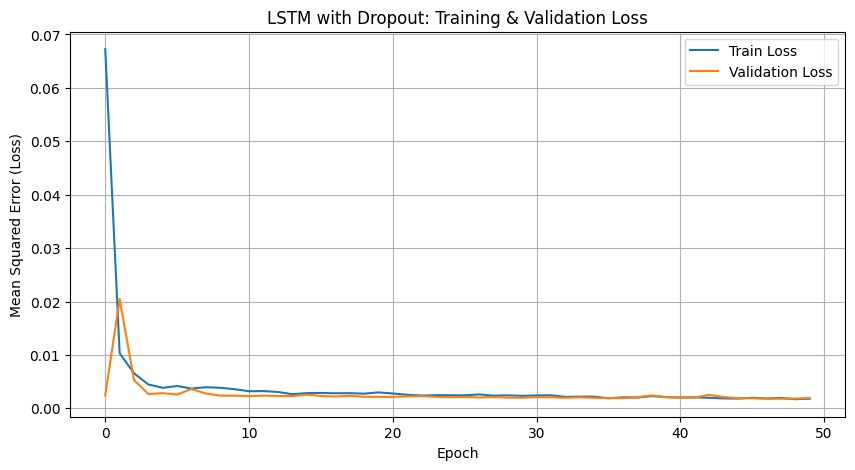

In [16]:
print("\n--- Experiment: LSTM with Dropout ---")
model_dropout_lstm = Sequential(name="Dropout_LSTM_Model")

# YOUR CODE HERE: Add an LSTM layer with 32 units, specifying input_shape.
model_dropout_lstm.add(LSTM(32, input_shape=input_shape))

# YOUR CODE HERE: Add a Dropout layer with a rate of 0.2 (20% dropout).
model_dropout_lstm.add(Dropout(0.2))

# YOUR CODE HERE: Add the Dense output layer with 1 unit.
model_dropout_lstm.add(Dense(1))

# YOUR CODE HERE: Compile the model ('adam', 'mean_squared_error').
model_dropout_lstm.compile(optimizer='adam', loss='mean_squared_error')

model_dropout_lstm.summary()

# --- Train and Evaluate Dropout LSTM ---
print(f"\nTraining LSTM with Dropout for {epochs} epochs...")
# YOUR CODE HERE: Train 'model_dropout_lstm' using .fit().
# Store the history in 'history_dropout'.
history_dropout = model_dropout_lstm.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)

# YOUR CODE HERE: Evaluate the trained 'model_dropout_lstm' on the test set.
# Store the result in 'mse_dropout'.
mse_dropout = model_dropout_lstm.evaluate(X_test, y_test, verbose=0)
print(f"LSTM with Dropout - Test MSE: {mse_dropout:.6f}")

# YOUR CODE HERE: Plot the loss curves for the dropout model.
plot_loss_curves(history_dropout, "LSTM with Dropout")

### 2e. Experiment: Different Lookback Period
Re-train the best performing model (likely LSTM or GRU) using a different `look_back` period.
Repeat the sequence creation, reshaping, and train/test split steps with `look_back = 30`. Then define, compile, train, and evaluate the chosen model architecture again.
The choice of lookback period is a hyperparameter. A shorter period (30 days) might focus more on recent trends, while a longer one (60 days) captures more historical context. This experiment helps understand how sensitive the model is to this choice.


--- Experiment: Shorter Lookback (30 days) with LSTM ---
Short Lookback Shapes:
X_train_short: (783, 30, 1) y_train_short: (783,)
X_test_short: (196, 30, 1) y_test_short: (196,)


C:\Users\isrtr\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM with 30-day Lookback...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.0566 - val_loss: 0.0029
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0025 - val_loss: 0.0030
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 12/50
22/22 ━━━━━━

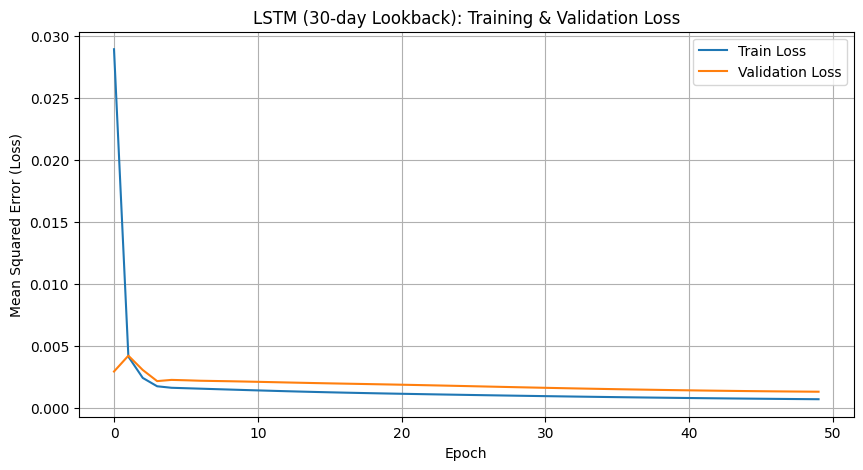

In [17]:
print("\n--- Experiment: Shorter Lookback (30 days) with LSTM ---")
look_back_short = 30

# YOUR CODE HERE: Re-create sequences using 'dataset_scaled' and 'look_back_short'. Store in X_short, y_short.
X_short, y_short = create_sequences(dataset_scaled, look_back_short)

# YOUR CODE HERE: Reshape X_short to the 3D format [samples, timesteps, features].
X_short = np.reshape(X_short, (X_short.shape[0], X_short.shape[1], 1))

# YOUR CODE HERE: Perform train/test split on X_short, y_short (80/20 split).
# Use the same train_size_percentage. Store results in X_train_short, X_test_short, y_train_short, y_test_short.
train_size_short = int(len(X_short) * train_size_percentage)
X_train_short, X_test_short = X_short[:train_size_short], X_short[train_size_short:]
y_train_short, y_test_short = y_short[:train_size_short], y_short[train_size_short:]

print("Short Lookback Shapes:")
print("X_train_short:", X_train_short.shape, "y_train_short:", y_train_short.shape)
print("X_test_short:", X_test_short.shape, "y_test_short:", y_test_short.shape)

# --- Build, Compile, Train, Evaluate LSTM with Short Lookback ---
model_lstm_short = Sequential(name="LSTM_ShortLookback_Model")
# YOUR CODE HERE: Add an LSTM layer with 32 units. The input_shape will use look_back_short.
model_lstm_short.add(LSTM(32, input_shape=(look_back_short, 1)))
# YOUR CODE HERE: Add the Dense output layer.
model_lstm_short.add(Dense(1))

# YOUR CODE HERE: Compile the model.
model_lstm_short.compile(optimizer='adam', loss='mean_squared_error')

print(f"\nTraining LSTM with {look_back_short}-day Lookback...")
# YOUR CODE HERE: Train 'model_lstm_short' using the _short datasets.
# Store history in 'history_lstm_short'. Use verbose=0.
history_lstm_short = model_lstm_short.fit(
    X_train_short, y_train_short,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)

# YOUR CODE HERE: Evaluate 'model_lstm_short' on the _short test set.
# Store mse in 'mse_lstm_short'.
mse_lstm_short = model_lstm_short.evaluate(X_test_short, y_test_short, verbose=0)
print(f"LSTM with {look_back_short}-day Lookback - Test MSE: {mse_lstm_short:.6f}")

# YOUR CODE HERE: Plot the loss curves for this short lookback model.
plot_loss_curves(history_lstm_short, f"LSTM ({look_back_short}-day Lookback)")

## Exercise 3: Analysis & Questions
Instructions: Answer the following questions based on the results you obtained by running the code above. Refer back to the MSE values, loss curves, and prediction plots.

**1. Initial Model Comparison (Ex 1):** 
    * Compare the **Test MSE** results from the SimpleRNN, GRU, and LSTM models (from section 1d).
    * Which model performed best (lowest Test MSE)? Which performed worst?
    * Does this outcome align with the theoretical advantages of LSTMs/GRUs (handling long-term dependencies better than SimpleRNNs)? Explain briefly.

**2. Prediction Plot Analysis (Ex 2b):** 
    * Looking at the plot comparing actual vs. predicted prices on the test set, which model's predictions (dashed lines) visually seemed to follow the actual price trend most closely?
    * Does the model that *looks* best on the plot necessarily have the lowest Test MSE you recorded in Ex 1d? Discuss any similarities or differences between your visual assessment and the MSE scores.\

**3. Task Type & Configuration:**
    * Why did we use `mean_squared_error` as the loss function for predicting stock prices, instead of a classification loss like `categorical_crossentropy`?
    * Why does the final `Dense` layer in all models have only 1 unit and use a `linear` (default) activation function?

**4. Input Shape Explanation:** For the input shape `[samples, timesteps, features]` used in this assignment:
    * What does the `samples` dimension represent (how many sequences did we create)?
    * What does the `timesteps` dimension represent (what value did we set for `look_back` initially)?
    * What does the `features` dimension represent (how many features did we use, and what was it)?

**5. Stacked LSTM (`return_sequences=True`) (Ex 2c):**
    * Explain *why* setting `return_sequences=True` on the *first* LSTM layer was necessary for the stacked model.
    * What is the shape of the output from an LSTM layer when `return_sequences=True` vs. `return_sequences=False` (the default)?

**6. Tuning Results Analysis (Ex 2c, 2d):** 
    * Compare the **Test MSE** of the simple LSTM (Ex 1d), the Stacked LSTM (Ex 2c), and the LSTM with Dropout (Ex 2d).
    * Did stacking LSTM layers improve performance over the single LSTM layer in this case? Suggest a reason why it might have helped or hurt.
    * Did adding Dropout improve performance over the single LSTM layer? Look at the loss curves for the Dropout model and the simple LSTM - does Dropout appear to reduce overfitting (i.e., is the gap between train and validation loss smaller)? Explain.

**7. Lookback Period Analysis (Ex 2e):**
    * Compare the **Test MSE** of the LSTM model with the original lookback (60 days, from Ex 1d) and the LSTM model with the shorter lookback (30 days, from Ex 2e).
    * Which lookback period resulted in better performance on the test set?
    * Why might a shorter or longer lookback period be better for predicting stock prices?

